<a href="https://colab.research.google.com/github/EliseMalvaoCarlson/Previs-o_de_Uso_Memoria_RAm/blob/main/Previs%C3%A3o_de_Uso_de_Mem%C3%B3ria_RAM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Projeto 3 - Precisão de Uso de Memória Ram

Disciplina ARA0024 / Modelagem Matemática

Período 2025.1


Turma: 1002


Prof.ª Anna Rafaela

# Importação das bibliotecas


In [76]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.interpolate import
from sklearn.metrics import mean_squared_error, r2_score

**pandas:** Para manipulação dos dados.

**numpy:** Para operações numéricas.

**matplotlib e seaborn:** Para visualizações gráficas.

**scipy.interpolate:** Para interpolação dos dados.

**scipy.interpolate:** Para interpolação de dados, permitindo estimar valores intermediários a partir de um conjunto de pontos conhecidos. É útil para prever tendências e preencher lacunas nos dados.

**mean_squared_error e r2_score (sklearn.metrics):** São métricas para avaliar modelos preditivos.
- mean_squared_error (MSE) mede a diferença média entre os valores reais e previstos (quanto menor, melhor).
- r2_score indica o ajuste do modelo (quanto mais próximo de 1, melhor a interpolação).

# Obtenção do dataset

In [60]:
# Leitura do dataset
url = "https://raw.githubusercontent.com/EliseMalvaoCarlson/Previs-o_de_Uso_Memoria_RAm/refs/heads/main/systemresources-deeplearning-1000.csv"
#Função pandas para ler arquivo.csv
tabela = pd.read_csv(url)
tabela.head()



,index,cpu,ram,disk,network
0,1,79,58,50,10
1,2,78,54,52,11
2,3,79,64,67,13
3,4,78,66,68,9
4,5,75,57,58,11


In [58]:
# Verifica o tamanho do dataframe
tabela.shape

(999, 5)

Optamos por salvar o dataset em repositório do Github e usamos o método URL para obtermos os dados aqui no Colab

# Tratando o dataset



In [57]:
# Verifica os nomes das coluna
print(tabela.columns)

# Verifica valores nulos (faltantes)
print(tabela.isnull().sum())


Index(['index', 'cpu', 'ram', 'disk', 'network'], dtype='object')
index      0
cpu        0
ram        0
disk       0
network    0
dtype: int64


In [12]:
# Contar valores negativos na coluna 'ram'
negativos_ram = (tabela['ram'] < 0).sum()
print(f"Quantidade de valores negativos na coluna 'ram': {negativos_ram}")


Quantidade de valores negativos na coluna 'ram': 29


In [13]:
# Calcular a porcentagem de valores negativos na coluna 'ram'
porcentagem_negativos_ram = (tabela['ram'] < 0).sum() / len(tabela) * 100
print(f"Porcentagem de valores negativos na coluna 'ram': {porcentagem_negativos_ram:.2f}%")


Porcentagem de valores negativos na coluna 'ram': 2.90%


In [68]:
# Selecionar apenas as colunas de interesse (CPU e RAM)
tabela = tabela[['cpu', 'ram']]

# Remove linhas com dados faltando
tabela = tabela.dropna()

# Remover linhas com valores negativos na coluna 'ram'
tabela = tabela[tabela['ram'] >= 0]

# Verifica o novo tamanho do dataset
print(tabela.shape)

# Remover valores NaN do dataset
ram = ram_values[~np.isnan(ram_values)]
cpu= cpu_values[~np.isnan(cpu_values)]



(970, 2)


# INTERPOLAÇÃO


Queremos prever o uso de memória em relação ao consumo da CPU usando interpolação

# Nativo (SciPy) - Linear


Text(0, 0.5, 'Uso de RAM')

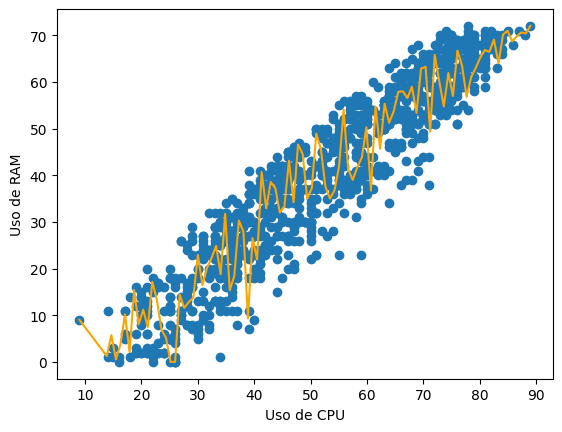

In [78]:
# Definir corretamente os valores de CPU e RAM
cpu_values = tabela['cpu'].values
ram_values = tabela['ram'].values

# Criar interpolador linear
interpolador = interp1d(cpu_values, ram_values, kind='linear', fill_value="extrapolate")

# Testar interpolação em valores de CPU não definidos
cpu_test = np.linspace(min(cpu_values), max(cpu_values), 100)
ram_pred = interpolador(cpu_test)

# Plotar interpolação
plt.scatter(cpu_values, ram_values, label="Dados Originais")
plt.plot(cpu_test, ram_pred, color='orange', label="Interpolação Linear")
plt.xlabel("Uso de CPU")
plt.ylabel("Uso de RAM")





interp1d: Método de interpolação linear do SciPy.

fill_value="extrapolate": Permite extrapolar valores além dos dados conhecidos.

linspace(): Gera valores intermediários para testar a interpolação.

# Customizado

Interpolação polinomial é um método matemático usado para estimar valores desconhecidos dentro de um intervalo de dados conhecidos. Basicamente, ele constrói um polinômio que passa pelos pontos fornecidos e usa esse polinômio para prever valores intermediários.

Imagine que você tem um conjunto de dados com o uso da CPU e o consumo de memória RAM. Se você quiser prever o consumo de RAM para um valor de CPU que não está exatamente no conjunto original, a interpolação polinomial pode ser usada para criar uma função que estima essa relação.



In [75]:
# Definir os limites do dataset
cpu_min = tabela['cpu'].min()
cpu_max = tabela['cpu'].max()

# Criar a interpolação polinomial
grau_polinomio = 3  # Escolha do grau do polinômio (ajustável)
coeficientes = np.polyfit(tabela['cpu'], tabela['ram'], grau_polinomio)
polinomio = np.poly1d(coeficientes)  # Criação do modelo polinomial

# Solicitar entrada do usuário para um único valor de CPU
try:
    cpu_input = float(input(f"Digite um valor de CPU ({cpu_min} a {cpu_max}): "))

    # Verificar se o valor está dentro do intervalo permitido
    if cpu_min <= cpu_input <= cpu_max:
        # Calcular interpolação de RAM usando o polinômio
        ram_interpolada = polinomio(cpu_input)
        print(f"Para CPU = {cpu_input}, a RAM interpolada é aproximadamente {ram_interpolada:.2f}")
    else:
        print(f"Por favor, insira um valor entre {cpu_min} e {cpu_max}.")

except ValueError:
    print("Entrada inválida! Certifique-se de digitar um número válido.")


Digite um valor de CPU (9 a 89): 5
Por favor, insira um valor entre 9 e 89.


A interpolação polinomial foi escolhida para modelar a relação entre o uso da CPU e o consumo de memória RAM porque permite capturar padrões mais complexos que um método linear tradicional não conseguiria. Ao ajustar um polinômio de grau 3 aos dados, conseguimos obter uma curva que reflete melhor as variações não lineares presentes no dataset. Esse método é útil para detectar tendências e comportamentos que um interpolador simples poderia ignorar.

O código é customizado, pois implementa manualmente a interpolação usando numpy.polyfit(), em vez de utilizar diretamente métodos nativos de interpolação da biblioteca SciPy, como interp1d(). Ao construir a função polinomial com poly1d(), o usuário tem mais controle sobre o grau do polinômio e a forma da estimativa, permitindo ajustes para um melhor desempenho dependendo do comportamento dos dados. Além disso, a interação com o usuário, onde ele insere um valor de CPU e recebe uma previsão personalizada, torna o código mais dinâmico e adaptável às necessidades específicas do problema.

## Comparação de Erros

Tamanho de dados reais: 970
Tamanho de previsão SciPy: 970
Tamanho de previsão Customizado: 970
Erro RMSE - Método SciPy: 9.4397
Erro RMSE - Método Customizado: 6.5460
Coeficiente R² - Método SciPy: 0.7432
Coeficiente R² - Método Customizado: 0.8765


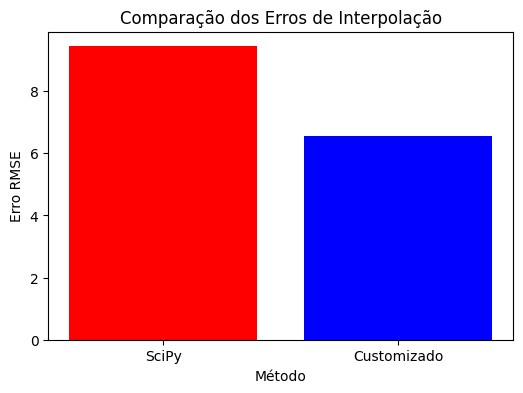

In [77]:
from sklearn.metrics import mean_squared_error, r2_score

# Criar previsões para cada método, usando os valores reais do dataset
cpu_values = tabela['cpu'].values  # Extrai os valores reais de CPU
ram_values = tabela['ram'].values  # Extrai os valores reais de RAM

# Gerar previsões usando interpolação SciPy e o método customizado
ram_pred_scipy = interpolador(cpu_values)  # Método do SciPy
ram_pred_custom = polinomio(cpu_values)    # Método Polinomial

# Verificar dimensões dos arrays para evitar erros
print(f"Tamanho de dados reais: {len(ram_values)}")
print(f"Tamanho de previsão SciPy: {len(ram_pred_scipy)}")
print(f"Tamanho de previsão Customizado: {len(ram_pred_custom)}")

# Cálculo do erro médio quadrático (RMSE)
rmse_scipy = np.sqrt(mean_squared_error(ram_values, ram_pred_scipy))
rmse_custom = np.sqrt(mean_squared_error(ram_values, ram_pred_custom))

# Coeficiente de determinação (R²)
r2_scipy = r2_score(ram_values, ram_pred_scipy)
r2_custom = r2_score(ram_values, ram_pred_custom)

print(f"Erro RMSE - Método SciPy: {rmse_scipy:.4f}")
print(f"Erro RMSE - Método Customizado: {rmse_custom:.4f}")
print(f"Coeficiente R² - Método SciPy: {r2_scipy:.4f}")
print(f"Coeficiente R² - Método Customizado: {r2_custom:.4f}")

# Gráfico de comparação dos erros
plt.figure(figsize=(6,4))
plt.bar(['SciPy', 'Customizado'], [rmse_scipy, rmse_custom], color=['red', 'blue'])
plt.xlabel("Método")
plt.ylabel("Erro RMSE")
plt.title("Comparação dos Erros de Interpolação")
plt.show()


# Derivação